<a href="https://colab.research.google.com/github/Samujjalborah/python-learning-journey/blob/main/Day18%2519/Day_18_%26_19_%E2%80%93_ML_Student_Performance_Prediction_and_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 18 & 19 – ML Student Performance Prediction and Model Evaluation

## Objective

This notebook demonstrates a complete machine learning workflow using the Student Performance dataset.

The notebook includes:

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Linear Regression
- Regression model evaluation
- Pass/Fail classification
- Classification model evaluation
- Overfitting and underfitting analysis
- Key insights and conclusion

Developed by: Samujjal Borah

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.style.use("default")
df = pd.read_csv("Student_performance.csv")

df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


Dataset Inspection

In [2]:
print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print()

print("="*60)
print("FIRST FIVE RECORDS")
print("="*60)
display(df.head())

print()

print("="*60)
print("DATA TYPES")
print("="*60)
display(df.dtypes)

print()

print("="*60)
print("MISSING VALUES")
print("="*60)

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

display(missing[missing["Missing Values"] > 0])

print()

print("="*60)
print("DUPLICATE RECORDS")
print("="*60)
print(df.duplicated().sum())

DATASET SHAPE
(1000, 16)

FIRST FIVE RECORDS


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4



DATA TYPES


,0
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object



MISSING VALUES


,Missing Values,Percentage
parental_education_level,91,9.1



DUPLICATE RECORDS
0


## Interpretation

- The dataset contains **1,000 student records** and **16 variables**, providing sufficient data for machine learning analysis.
- No duplicate records were found.
- Only one column, **parental_education_level**, contains missing values (**91 records; 9.1%**). This will be handled during data preprocessing.
- The dataset contains both **numerical** and **categorical** variables, making it suitable for exploratory analysis and predictive modeling.

#Exploratory Data Analysis (EDA)

5.1 Separate Numerical and Categorical Variables

In [3]:
numerical = df.select_dtypes(include="number")
categorical = df.select_dtypes(include="object")

print("Numerical Columns")
print(numerical.columns.tolist())

print("\nCategorical Columns")
print(categorical.columns.tolist())

Numerical Columns
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical Columns
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


### Interpretation

- The dataset contains **9 numerical variables** and **7 categorical variables**.
- Numerical variables will be used directly in the regression model after preprocessing.
- Categorical variables will require encoding before they can be used in machine learning models.

5.2 Descriptive Statistics

In [4]:
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

display(df.describe())

DESCRIPTIVE STATISTICS


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


### Interpretation

- The average student studies approximately **3.55 hours per day**.
- Students attend around **84% of classes** on average.
- The average exam score is **69.60 marks**, with scores ranging from **18.4 to 100**.
- Sleep duration averages **6.47 hours**, suggesting most students sleep between 5–7 hours.
- Mental health ratings vary widely, indicating diverse wellbeing among students.

5.3 Correlation Matrix

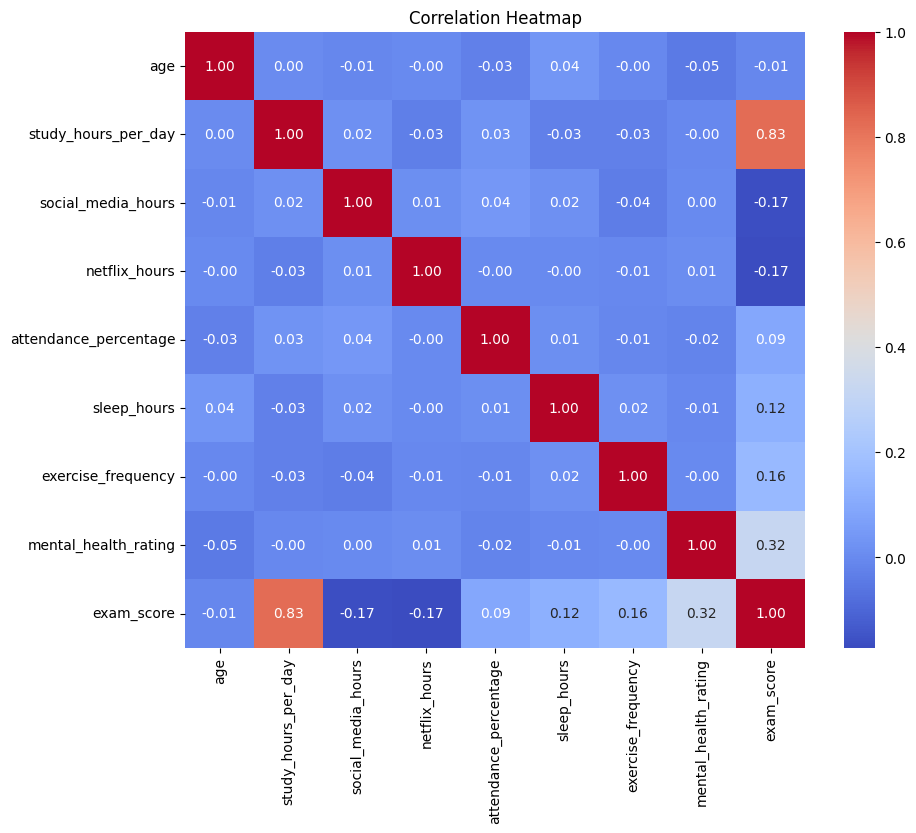

In [5]:
corr = numerical.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Interpretation

- **Study hours per day** has the strongest positive correlation with exam score (**0.83**), indicating that students who study more generally achieve higher scores.
- **Mental health rating** shows a moderate positive relationship (**0.32**) with exam score.
- **Exercise frequency** has a small positive correlation (**0.16**), suggesting regular exercise may slightly improve academic performance.
- **Attendance percentage** (**0.09**) and **sleep hours** (**0.12**) have weak positive relationships with exam score.
- **Social media hours (-0.17)** and **Netflix hours (-0.17)** show weak negative correlations, indicating that excessive entertainment may reduce academic performance.
- Age has almost no relationship with exam score.

5.4 Distribution of Exam Scores

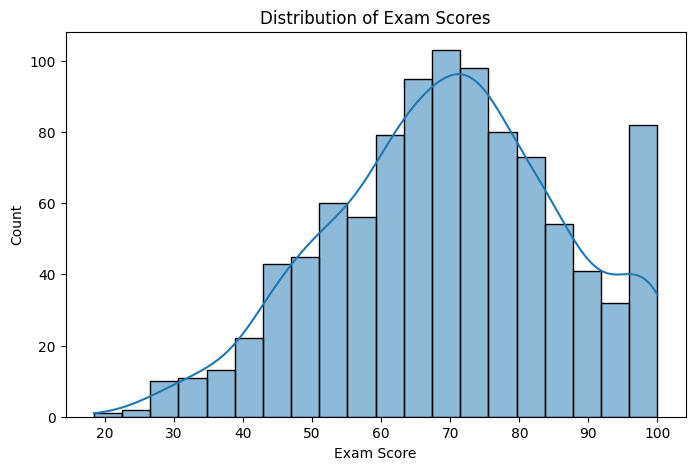

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["exam_score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Count")

plt.show()

### Interpretation

- Exam scores are approximately normally distributed.
- Most students scored between **60 and 85 marks**.
- Very few students obtained extremely low or extremely high scores.
- The distribution appears suitable for regression modelling.

5.5 Study Hours vs Exam Score

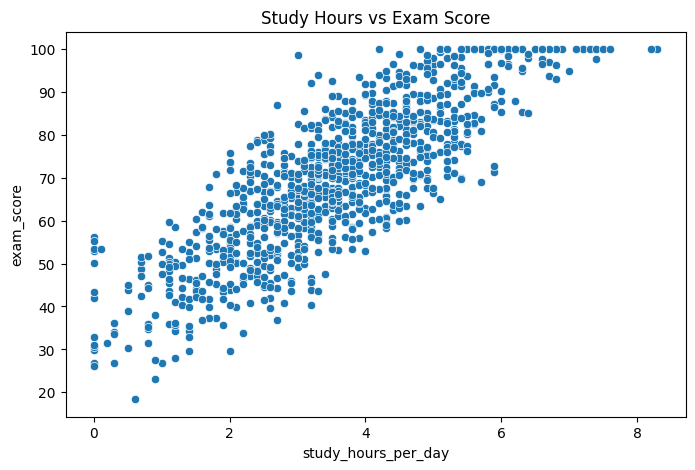

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="study_hours_per_day",
    y="exam_score"
)

plt.title("Study Hours vs Exam Score")

plt.show()

### Interpretation

- A strong positive linear relationship exists between study hours and exam score.
- Students studying more hours generally achieve higher marks.
- This variable is expected to be one of the strongest predictors in the regression model.

5.6 Attendance vs Exam Score

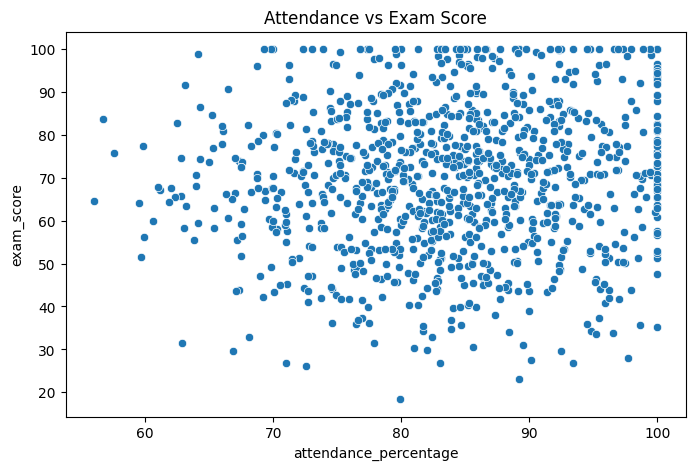

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="attendance_percentage",
    y="exam_score"
)

plt.title("Attendance vs Exam Score")

plt.show()

### Interpretation

- Attendance shows only a weak positive relationship with exam score.
- Students with high attendance can still achieve both low and high scores.
- Attendance alone is not a strong predictor of academic performance.

5.7 Sleep Hours vs Exam Score

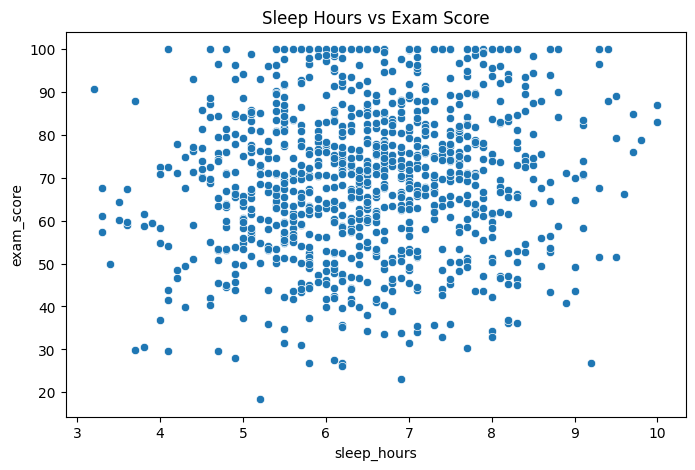

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="sleep_hours",
    y="exam_score"
)

plt.title("Sleep Hours vs Exam Score")

plt.show()

### Interpretation

- Sleep hours show a slight positive relationship with exam score.
- Students sleeping around 6–8 hours tend to perform slightly better.
- However, sleep alone does not strongly determine exam performance.

5.8 Boxplot (Outlier Detection)

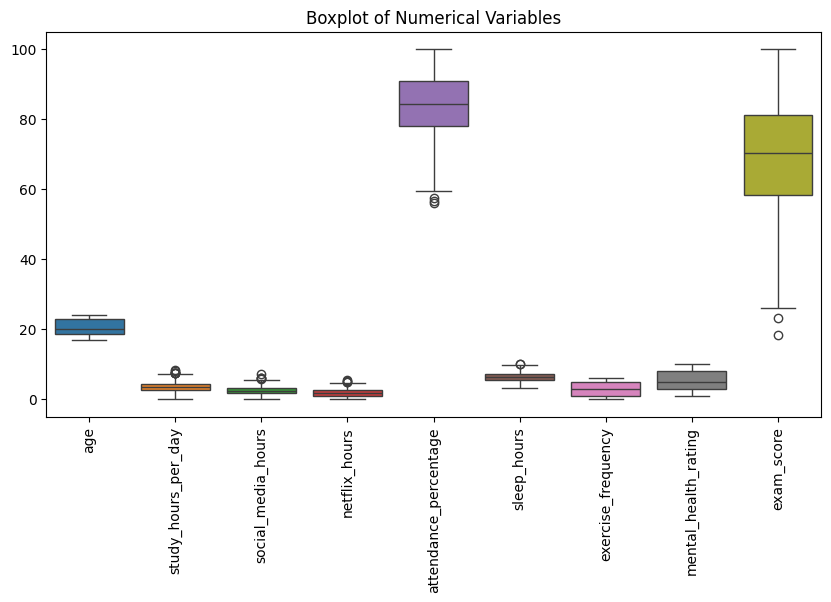

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(data=numerical)

plt.xticks(rotation=90)

plt.title("Boxplot of Numerical Variables")

plt.show()

### Interpretation

- Most numerical variables contain a few outliers.
- Exam scores and attendance have some extreme observations.
- No severe abnormalities are observed, so the dataset remains suitable for machine learning after preprocessing.

## EDA Summary

The exploratory analysis indicates that **study_hours_per_day** is the strongest factor associated with exam performance. Mental health, exercise frequency, and sleep hours show moderate to weak positive relationships, while excessive social media and Netflix usage show weak negative relationships. The dataset contains only one column with missing values, no duplicate records, and no severe outlier issues that would prevent machine learning analysis.

#Step 1 — Data Preprocessing
# Data Preprocessing

In this section, the dataset is prepared for machine learning by handling missing values, encoding categorical variables, selecting features, and splitting the dataset into training and testing sets.

#Step 2 — Import ML Libraries

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#Step 3 — Handle Missing Values

In [12]:
df_ml = df.copy()

df_ml["parental_education_level"] = (
    df_ml["parental_education_level"]
    .fillna(df_ml["parental_education_level"].mode()[0])
)

#Step 4 — Encode Categorical Variables

In [13]:
label_encoder = LabelEncoder()

categorical_columns = df_ml.select_dtypes(include="object").columns

for col in categorical_columns:
    df_ml[col] = label_encoder.fit_transform(df_ml[col])

df_ml.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,0,23,0,0.0,1.2,1.1,0,85.0,8.0,0,6,2,0,8,1,56.2
1,1,20,0,6.9,2.8,2.3,0,97.3,4.6,1,6,1,0,8,0,100.0
2,2,21,1,1.4,3.1,1.3,0,94.8,8.0,2,1,1,2,1,0,34.3
3,3,23,0,1.0,3.9,1.0,0,71.0,9.2,2,4,2,1,1,1,26.8
4,4,19,0,5.0,4.4,0.5,0,90.9,4.9,0,3,2,1,1,0,66.4


#Step 5 — Select Features and Target

In [14]:
X = df_ml.drop("exam_score", axis=1)
y = df_ml["exam_score"]

#Step 6 — Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples: (800, 15)
Testing samples : (200, 15)


#Step 7 — Interpretation

- Missing values in the parental education column were replaced using the most frequent category.
- All categorical variables were converted into numerical values using Label Encoding.
- The target variable is **exam_score**.
- The dataset was divided into **80% training data** and **20% testing data** for model evaluation.

#Step 8 — Train the Linear Regression Model
# Linear Regression Model

A Linear Regression model is trained to predict students' exam scores using the selected features.

In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

#Step 9 — Make Predictions

In [17]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


#Step 10 — Evaluate the Regression Model

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("="*60)
print("LINEAR REGRESSION EVALUATION")
print("="*60)

print()

print("Training Performance")
print("---------------------")
print("MAE :", round(mean_absolute_error(y_train,y_train_pred),2))
print("MSE :", round(mean_squared_error(y_train,y_train_pred),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_train,y_train_pred)),2))
print("R² :", round(r2_score(y_train,y_train_pred),3))

print()

print("Testing Performance")
print("--------------------")
print("MAE :", round(mean_absolute_error(y_test,y_test_pred),2))
print("MSE :", round(mean_squared_error(y_test,y_test_pred),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test,y_test_pred)),2))
print("R² :", round(r2_score(y_test,y_test_pred),3))

LINEAR REGRESSION EVALUATION

Training Performance
---------------------
MAE : 4.22
MSE : 28.67
RMSE: 5.35
R² : 0.902

Testing Performance
--------------------
MAE : 4.18
MSE : 26.55
RMSE: 5.15
R² : 0.896


#Step 11 — Plot Actual vs Predicted

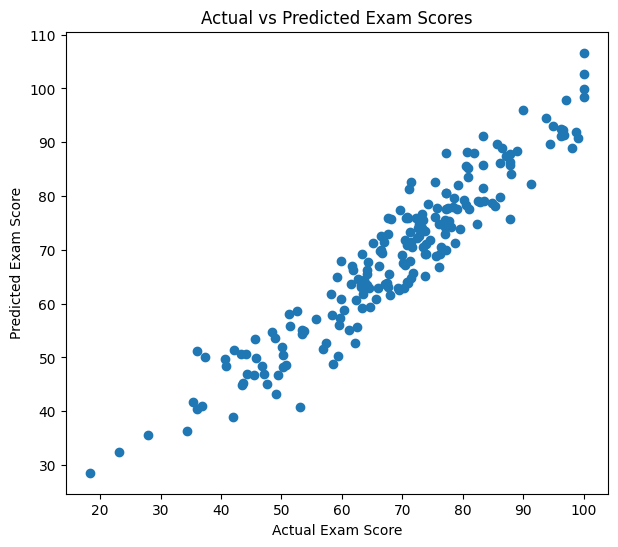

In [19]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_test_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

#Step 12 — Interpretation

- The Linear Regression model achieved a Training R² score of **0.902** and a Testing R² score of **0.896**, indicating that it explains nearly 90% of the variation in students' exam scores.
- The testing errors were low (MAE = **4.18**, RMSE = **5.15**), meaning the predicted scores are generally within about 5 marks of the actual scores.
- The Actual vs Predicted scatter plot shows that most points lie close to the diagonal trend, indicating strong predictive performance.
- The training and testing performances are very similar, suggesting that the model generalizes well and does **not** show significant signs of overfitting or underfitting.

#Step 13 — Create Pass/Fail Target

In [20]:
df["Pass_Fail"] = np.where(df["exam_score"] >= 50, 1, 0)

df["Pass_Fail"].value_counts()

,count
Pass_Fail,
1,869
0,131


#Step 14 — Prepare Features Again

In [21]:
X = df.drop(columns=["student_id", "exam_score", "Pass_Fail"])
y = df["Pass_Fail"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#Step 15 — Train Classification Model

In [22]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42)

classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

#Step 16 — Predictions

In [23]:
y_pred = classifier.predict(X_test)

#Step 17 — Evaluation

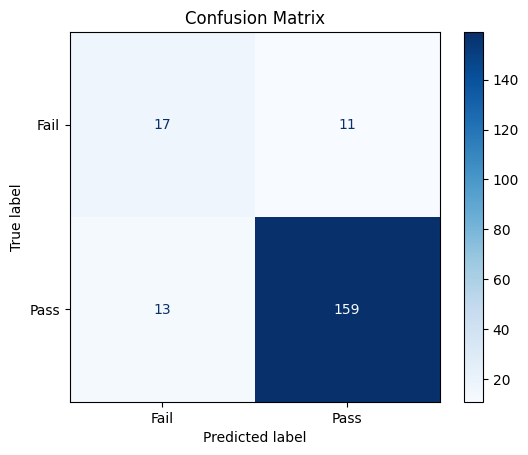

CLASSIFICATION EVALUATION
Accuracy : 0.880
Precision: 0.935
Recall   : 0.924
F1-score : 0.930

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.61      0.59        28
           1       0.94      0.92      0.93       172

    accuracy                           0.88       200
   macro avg       0.75      0.77      0.76       200
weighted avg       0.88      0.88      0.88       200



In [24]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("="*60)
print("CLASSIFICATION EVALUATION")
print("="*60)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

#Step 18 — Interpretation
# Classification Model Interpretation

- The Decision Tree Classifier achieved an accuracy of **88.0%**, indicating that it correctly classified most students as Pass or Fail.
- The model achieved a **Precision of 93.5%**, meaning that when it predicted a student would pass, it was usually correct.
- The **Recall of 92.4%** indicates that the model successfully identified most of the students who actually passed.
- The **F1-score of 93.0%** shows a good balance between precision and recall.
- The confusion matrix shows that most students were classified correctly, although a few pass and fail cases were misclassified.

#Step 19 — Training vs Testing Comparison
# Training vs Testing Performance

## Regression Model

| Metric | Training | Testing |
|---------|----------|----------|
| R² | 0.902 | 0.896 |
| RMSE | 5.35 | 5.15 |

### Interpretation

- The training and testing R² scores are very similar.
- The RMSE values are also nearly identical.
- Therefore, the model generalizes well on unseen data.
- There are no significant signs of overfitting or underfitting.

#Step 20 — Final Insights
# Final Insights

1. Study hours per day showed the strongest positive relationship with exam scores.
2. Better mental health ratings were associated with improved academic performance.
3. Students spending excessive time on social media or Netflix generally obtained slightly lower exam scores.
4. The Linear Regression model explained nearly 90% of the variation in exam scores, demonstrating strong predictive performance.
5. The Decision Tree classifier achieved 88% accuracy in predicting Pass/Fail outcomes, making it effective for student performance classification.